In [58]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
import math
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score
from torchmetrics.classification import MulticlassCalibrationError
import json
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient
import time
from time import perf_counter



CURRENT_SEED = 17
COMPONENTS   = [32, 16, 8, 4]
N_QUBITS = 8

os.makedirs('../compressedFeatures', exist_ok=True)

# Angular Scaling
Scala le feature compresse in (0, 2π] con min-max. Fit solo su train e transform su tutti e tre gli split.

In [59]:
def angular_scaling(X_train, X_val, X_test):

    scaler = MinMaxScaler(feature_range=(1e-6, np.pi)) #1e-6 perchè nn deve essere 0
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)


    X_val_scaled  = np.clip(X_val_scaled,  1e-6, np.pi)
    X_test_scaled = np.clip(X_test_scaled, 1e-6, np.pi)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

In [60]:
for d in COMPONENTS:

    path = f'../compressedFeatures/pca_d{d}_seed_{CURRENT_SEED}.pt'
    ckpt = torch.load(path, weights_only=False)

    X_train = ckpt['train'].numpy()
    X_val   = ckpt['val'].numpy()
    X_test  = ckpt['test'].numpy()


    X_train_ang, X_val_ang, X_test_ang, scaler = angular_scaling(
        X_train, X_val, X_test
    )

    print(f'd={d:2d} \nrange train: [{X_train_ang.min():.4f}, {X_train_ang.max():.4f}]')
    print(f'range val:   [{X_val_ang.min():.4f}, {X_val_ang.max():.4f}]')
    print(f'range test:  [{X_test_ang.min():.4f}, {X_test_ang.max():.4f}]\n')


    torch.save({
        'train_ang':       torch.from_numpy(X_train_ang).float(),
        'val_ang':         torch.from_numpy(X_val_ang).float(),
        'test_ang':        torch.from_numpy(X_test_ang).float(),
        'y_train':         ckpt['y_train'],
        'y_val':           ckpt['y_val'],
        'y_test':          ckpt['y_test'],
        'd':               d,
        'seed':            CURRENT_SEED,
        'angular_scaling': 'minmax_(0,2pi]'
    }, f'../compressedFeatures/angular_d{d}_seed_{CURRENT_SEED}.pt')

d=32 
range train: [0.0000, 3.1416]
range val:   [0.0000, 3.1416]
range test:  [0.0000, 3.1416]

d=16 
range train: [0.0000, 3.1416]
range val:   [0.0000, 3.1416]
range test:  [0.0000, 3.1416]

d= 8 
range train: [0.0000, 3.1416]
range val:   [0.0000, 3.1416]
range test:  [0.0000, 2.9863]

d= 4 
range train: [0.0000, 3.1416]
range val:   [0.0000, 3.1416]
range test:  [0.0197, 2.5099]



# Angle Encoding con Data Re-Uploading

In [61]:
def build_encoding_layer(d, n_qubits, block_idx):

    # Costruisce un layer di encoding RY per un singolo blocco. Restituisce il circuito e i parametri di encoding del blocco.

    params = ParameterVector(f'x_{block_idx}', n_qubits) # ParameterVector è una lista di variabili simboliche non ha ancora valori numerici, sono solo nomi che venmgono sostituiti quando si esegue il circuito
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.ry(params[i], i)
    return qc, params

def build_encoding_circuit(d, n_qubits=N_QUBITS):

    # Costruisce il circuito di encoding completo con data re-uploading. Per ogni blocco di nqubits feature applica RY su tutti i qubit.
    # Se d non è divisibile per n_qubits, l'ultimo blocco viene zero-paddato.

    n_blocks = math.ceil(d / n_qubits)
    
    qc = QuantumCircuit(n_qubits)
    all_input_params = []

    for block in range(n_blocks):
        enc_layer, enc_params = build_encoding_layer(d, n_qubits, block)
        qc.compose(enc_layer, inplace=True)
        all_input_params.extend(enc_params)

    return qc, all_input_params, n_blocks

# verifica per ogni d
for d in COMPONENTS:
    qc, input_params, n_blocks = build_encoding_circuit(d, N_QUBITS)
    print(f'd={d:2d} | blocchi={n_blocks} | parametri encoding={len(input_params)} | padding={n_blocks*N_QUBITS - d}')


d=32 | blocchi=4 | parametri encoding=32 | padding=0
d=16 | blocchi=2 | parametri encoding=16 | padding=0
d= 8 | blocchi=1 | parametri encoding=8 | padding=0
d= 4 | blocchi=1 | parametri encoding=8 | padding=4


In [62]:
qc_example, _, _ = build_encoding_circuit(d=32, n_qubits=N_QUBITS)
qc_example.draw('text')
#qc_example.draw('mpl')
#qc_example.draw('latex')

┌────────────┐┌────────────┐┌────────────┐┌────────────┐
q_0: ┤ Ry(x_0[0]) ├┤ Ry(x_1[0]) ├┤ Ry(x_2[0]) ├┤ Ry(x_3[0]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_1: ┤ Ry(x_0[1]) ├┤ Ry(x_1[1]) ├┤ Ry(x_2[1]) ├┤ Ry(x_3[1]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_2: ┤ Ry(x_0[2]) ├┤ Ry(x_1[2]) ├┤ Ry(x_2[2]) ├┤ Ry(x_3[2]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_3: ┤ Ry(x_0[3]) ├┤ Ry(x_1[3]) ├┤ Ry(x_2[3]) ├┤ Ry(x_3[3]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_4: ┤ Ry(x_0[4]) ├┤ Ry(x_1[4]) ├┤ Ry(x_2[4]) ├┤ Ry(x_3[4]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_5: ┤ Ry(x_0[5]) ├┤ Ry(x_1[5]) ├┤ Ry(x_2[5]) ├┤ Ry(x_3[5]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_6: ┤ Ry(x_0[6]) ├┤ Ry(x_1[6]) ├┤ Ry(x_2[6]) ├┤ Ry(x_3[6]) ├
     ├────────────┤├────────────┤├────────────┤├────────────┤
q_7: ┤ Ry(x_0[7]) ├┤ Ry(x_1[7]) ├┤ Ry(x_2[7]) ├┤ Ry(x_3[7]) ├
     └────────────┘└────────────┘└────────────┘└────────────┘

# Ansatz RealAmplitudes Shallow

Ansatz 2-local che agisce su coppie di qubit adiacenti. È composto da due tipi di gate alternati:
- gate RY su ogni qubit con un parametro variazionale (layer di rotazione)
- gate CNOT tra qubit adiacenti che creano correlazioni quantistiche (layer di entanglement)

Visto che è shallow -> reps = 1

In [63]:
def build_ansatz_layer(n_qubits, reps, entanglement, block_idx=0, shared=True):
    """
    shared=True  → tutti i blocchi usano gli stessi parametri θ (vero data re-uploading)
                   d=8→16 params, d=16→16 params, d=32→16 params
    shared=False → ogni blocco ha parametri propri θ_{block_idx} (vecchio comportamento)
                   d=8→16 params, d=16→32 params, d=32→64 params
    """
    prefix = 'θ' if shared else f'θ_{block_idx}'
    ansatz = real_amplitudes(
        num_qubits=n_qubits,
        reps=reps,
        entanglement=entanglement,
        parameter_prefix=prefix
    )
    return ansatz

In [64]:
def build_vqc_circuit(d, n_qubits=N_QUBITS, reps=1, entanglement='linear', shared_params=True):
    n_blocks = math.ceil(d / n_qubits)
    qc = QuantumCircuit(n_qubits)
    all_input_params = []

    # crea UN solo template ansatz con parametri condivisi
    ansatz_template = build_ansatz_layer(n_qubits, reps, entanglement, block_idx=0, shared=True)

    for block in range(n_blocks):
        enc_layer, enc_params = build_encoding_layer(d, n_qubits, block)
        qc.compose(enc_layer, inplace=True)
        all_input_params.extend(enc_params)

        if shared_params:
            # stesso ansatz (stessi θ) ripetuto — vero re-uploading
            qc.compose(ansatz_template, inplace=True)
        else:
            # parametri indipendenti per blocco — vecchio comportamento
            ansatz_block = build_ansatz_layer(n_qubits, reps, entanglement, block, shared=False)
            qc.compose(ansatz_block, inplace=True)

    # con shared_params=True: sempre 16 var_params indipendentemente da d
    all_variational_params = list(ansatz_template.parameters)

    return qc, all_input_params, all_variational_params, n_blocks

In [65]:
print("=== shared_params=True (vero re-uploading) ===")
for d in COMPONENTS:
    qc, inp, var, nb = build_vqc_circuit(d, N_QUBITS, shared_params=True)
    n_cnot = qc.count_ops().get('cx', 0)
    print(f'd={d:2d} | blocchi={nb} | input={len(inp):2d} | var_params={len(var):2d} | CNOT={n_cnot}')

print("\n=== shared_params=False (vecchio comportamento) ===")
for d in COMPONENTS:
    qc, inp, var, nb = build_vqc_circuit(d, N_QUBITS, shared_params=False)
    print(f'd={d:2d} | blocchi={nb} | input={len(inp):2d} | var_params={len(var):2d}')

=== shared_params=True (vero re-uploading) ===
d=32 | blocchi=4 | input=32 | var_params=16 | CNOT=28
d=16 | blocchi=2 | input=16 | var_params=16 | CNOT=14
d= 8 | blocchi=1 | input= 8 | var_params=16 | CNOT=7
d= 4 | blocchi=1 | input= 8 | var_params=16 | CNOT=7

=== shared_params=False (vecchio comportamento) ===
d=32 | blocchi=4 | input=32 | var_params=16
d=16 | blocchi=2 | input=16 | var_params=16
d= 8 | blocchi=1 | input= 8 | var_params=16
d= 4 | blocchi=1 | input= 8 | var_params=16


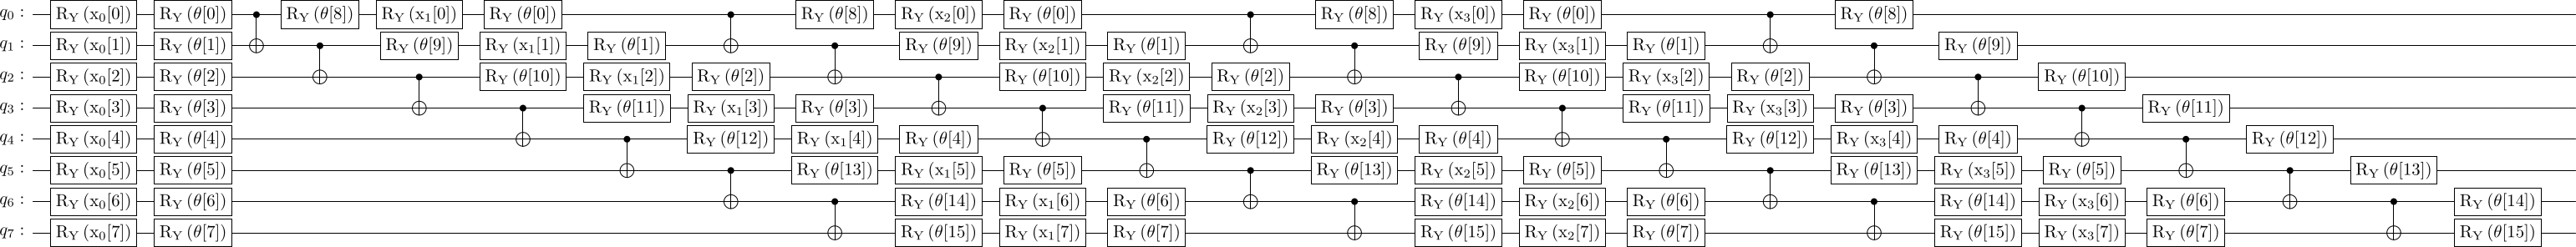

In [66]:
qc_example, _, _, _ = build_vqc_circuit(d=32, n_qubits=N_QUBITS)
qc_example.draw('latex')

In [67]:
def single_pauli_observables(n_qubits, op):
    observables = []
    for qubit in range(n_qubits):
        pauli = ["I"] * n_qubits
        pauli[n_qubits - 1 - qubit] = op
        observables.append(SparsePauliOp.from_list([("".join(pauli), 1.0)]))
    return observables

def pair_pauli_observables(n_qubits, op, pairs):
    """Osservabili a due qubit: op_i ⊗ op_j per le coppie indicate."""
    observables = []
    for (i, j) in pairs:
        pauli = ["I"] * n_qubits
        pauli[n_qubits - 1 - i] = op
        pauli[n_qubits - 1 - j] = op
        observables.append(SparsePauliOp.from_list([("".join(pauli), 1.0)]))
    return observables

def build_readout_observables(n_qubits, readout="z"):
    singles_xyz = (single_pauli_observables(n_qubits, "X")
                 + single_pauli_observables(n_qubits, "Y")
                 + single_pauli_observables(n_qubits, "Z"))

    if readout == "z":
        return single_pauli_observables(n_qubits, "Z")
    elif readout == "x_z":
        return (single_pauli_observables(n_qubits, "X")
              + single_pauli_observables(n_qubits, "Z"))
    elif readout == "x_y_z":
        return singles_xyz
    elif readout == "x_y_z_pair_nn":
        nn_pairs = [(i, i+1) for i in range(n_qubits - 1)]
        pair_obs = []
        for op in ["X", "Y", "Z"]:
            pair_obs += pair_pauli_observables(n_qubits, op, nn_pairs)
        return singles_xyz + pair_obs          # 24 + 21 = 45
    elif readout == "x_y_z_pair_all":
        all_pairs = [(i, j) for i in range(n_qubits) for j in range(i+1, n_qubits)]
        pair_obs = []
        for op in ["X", "Y", "Z"]:
            pair_obs += pair_pauli_observables(n_qubits, op, all_pairs)
        return singles_xyz + pair_obs          # 24 + 84 = 108
    else:
        raise ValueError(f"Readout non supportato: {readout}")

for readout in ["z", "x_z", "x_y_z", "x_y_z_pair_nn", "x_y_z_pair_all"]:
    obs = build_readout_observables(N_QUBITS, readout)
    print(f'readout={readout:20s} → {len(obs):3d} osservabili → Linear({len(obs)}, 4)')

readout=z                    →   8 osservabili → Linear(8, 4)
readout=x_z                  →  16 osservabili → Linear(16, 4)
readout=x_y_z                →  24 osservabili → Linear(24, 4)
readout=x_y_z_pair_nn        →  45 osservabili → Linear(45, 4)
readout=x_y_z_pair_all       → 108 osservabili → Linear(108, 4)


In [68]:
def print_circuit_info(d, n_qubits=N_QUBITS, reps=1, entanglement='linear', readout="z"):
    qc, input_params, var_params, n_blocks = build_vqc_circuit(d, n_qubits, reps, entanglement)
    observables = build_readout_observables(n_qubits, readout)
    print(f'd={d:2d} | readout={readout}')
    print(f'  input_params : {len(input_params)}')
    print(f'  var_params   : {len(var_params)}')
    print(f'  readout_dim  : {len(observables)} → Linear({len(observables)}, 4)')
    print(f'  → OK\n')

for d in COMPONENTS:
    print_circuit_info(d, N_QUBITS)

d=32 | readout=z
  input_params : 32
  var_params   : 16
  readout_dim  : 8 → Linear(8, 4)
  → OK

d=16 | readout=z
  input_params : 16
  var_params   : 16
  readout_dim  : 8 → Linear(8, 4)
  → OK

d= 8 | readout=z
  input_params : 8
  var_params   : 16
  readout_dim  : 8 → Linear(8, 4)
  → OK

d= 4 | readout=z
  input_params : 8
  var_params   : 16
  readout_dim  : 8 → Linear(8, 4)
  → OK



In [69]:
import qiskit_aer
import qiskit_machine_learning
print(f'qiskit-aer: {qiskit_aer.__version__}')
print(f'qiskit-machine-learning: {qiskit_machine_learning.__version__}')

qiskit-aer: 0.17.2
qiskit-machine-learning: 0.9.0


In [70]:
class _BatchedEstimatorPauliSPSAFunction(torch.autograd.Function):
    """
    Custom autograd Function che integra SPSA nel grafo PyTorch.
    - forward : calcola le aspettazioni Pauli via EstimatorV2 batched
    - backward: stima il gradiente rispetto a q_weights via SPSA
                grad_input = None → SPSA non aggiorna gli input (solo i pesi)
    """
    @staticmethod
    def forward(ctx, model, x, weights):
        features = model._estimate_readout_features(
            x.detach().cpu().numpy().astype(np.float64),
            weights.detach().cpu().numpy().astype(np.float64),
        )
        ctx.model = model
        ctx.save_for_backward(x.detach(), weights.detach())
        return torch.tensor(features, dtype=x.dtype, device=x.device)

    @staticmethod
    def backward(ctx, grad_output):
        x, weights = ctx.saved_tensors
        model = ctx.model
        grad_weights = model._spsa_weight_gradient(
            x.detach().cpu().numpy().astype(np.float64),
            weights.detach().cpu().numpy().astype(np.float64),
            grad_output.detach().cpu().numpy().astype(np.float64),
        )
        return None, None, torch.tensor(grad_weights, dtype=weights.dtype, device=weights.device)


class HybridVQC(nn.Module):
    """
    Modello ibrido quantistico-classico.
    - q_weights e head sono entrambi nn.Parameter → un solo ottimizzatore Adam
    - forward usa EstimatorV2 batched (una sola chiamata per tutto il batch)
    - backward usa SPSA solo su q_weights (non sugli input)
    """
    def __init__(self, quantum_circuit, observables, input_params, weight_params,
                 readout_dim, seed=CURRENT_SEED,
                 spsa_epsilon=0.1, spsa_batch_size=1,
                 estimator_precision=0.0, use_gpu=True):
        super().__init__()

        self.quantum_circuit  = quantum_circuit
        self.input_params     = input_params
        self.weight_params    = weight_params
        self.readout_dim      = readout_dim
        self.spsa_epsilon     = float(spsa_epsilon)
        self.spsa_batch_size  = int(spsa_batch_size)
        self.estimator_precision = float(estimator_precision)
        self._spsa_rng        = np.random.default_rng(seed)

        # AerEstimator con GPU opzionale
        self.estimator = AerEstimator()
        sim_opts = {"method": "statevector"}
        if use_gpu:
            try:
                sim_opts.update({"device": "GPU", "cuStateVec_enable": True})
                print("  GPU attiva: cuStateVec abilitato")
            except Exception as e:
                print(f"  GPU non disponibile ({e}), uso CPU")
        self.estimator.options.simulator = sim_opts
        self.estimator.options.shots = None
        self.estimator.options.max_parallel_threads = 0
        self.estimator.options.max_parallel_experiments = 0

        # pesi quantistici come nn.Parameter
        np.random.seed(seed)
        init_w = np.random.uniform(-0.01, 0.01, len(list(weight_params))).astype(np.float32)
        self.q_weights = nn.Parameter(torch.tensor(init_w))

        # testa classica
        self.head = nn.Linear(readout_dim, 4)

        # osservabili in formato EstimatorV2: lista di liste
        self.observables = [[obs] for obs in observables]

        # mappa ordine parametri circuito → [input_params | weight_params]
        source_params = list(input_params) + list(weight_params)
        source_index  = {p: i for i, p in enumerate(source_params)}
        self._parameter_order = list(quantum_circuit.parameters)
        try:
            self._parameter_source_indices = np.array(
                [source_index[p] for p in self._parameter_order], dtype=np.int64
            )
        except KeyError as e:
            raise RuntimeError(f"Parametro non tracciato nel circuito: {e}")

        print(f'  q_weights : {self.q_weights.shape}')
        print(f'  head      : Linear({readout_dim}, 4)')

    def _ordered_parameter_values(self, input_values, weights):
        if input_values.ndim == 1:
            input_values = input_values.reshape(1, -1)
        if weights.ndim == 1:
            weight_values = np.broadcast_to(weights, (input_values.shape[0], weights.shape[0]))
        else:
            weight_values = weights
        source_values = np.concatenate([input_values, weight_values], axis=1)
        return source_values[:, self._parameter_source_indices]

    def _estimate_readout_features(self, input_values, weights):
        """Una sola chiamata EstimatorV2 per tutto il batch."""
        parameter_values = self._ordered_parameter_values(input_values, weights)
        pub    = (self.quantum_circuit, self.observables, parameter_values)
        result = self.estimator.run([pub], precision=self.estimator_precision).result()
        evs    = np.asarray(result[0].data.evs, dtype=np.float64)
        expected = self.readout_dim * input_values.shape[0]
        if evs.size != expected:
            raise RuntimeError(f"evs size={evs.size}, atteso {expected}")
        return evs.reshape(self.readout_dim, input_values.shape[0]).T

    def _spsa_weight_gradient(self, input_values, weights, upstream_gradient):
        """SPSA solo sui pesi quantistici — non sugli input."""
        deltas = self._spsa_rng.choice(
            np.array([-1.0, 1.0], dtype=np.float64),
            size=(self.spsa_batch_size, weights.shape[0])
        )
        perturbed = []
        for delta in deltas:
            perturbed.append(weights + self.spsa_epsilon * delta)
            perturbed.append(weights - self.spsa_epsilon * delta)

        # tutte le valutazioni in una sola chiamata
        perturbed_weights = np.repeat(np.stack(perturbed), input_values.shape[0], axis=0)
        repeated_inputs   = np.tile(input_values, (len(perturbed), 1))
        features = self._estimate_readout_features(repeated_inputs, perturbed_weights)
        features = features.reshape(len(perturbed), input_values.shape[0], -1)

        grad = np.zeros_like(weights, dtype=np.float64)
        for idx, delta in enumerate(deltas):
            plus  = features[2 * idx]
            minus = features[2 * idx + 1]
            directional = np.sum(upstream_gradient * (plus - minus)) / (2.0 * self.spsa_epsilon)
            grad += directional * delta
        return grad / float(self.spsa_batch_size)

    def forward(self, x):
        q_out  = _BatchedEstimatorPauliSPSAFunction.apply(self, x, self.q_weights)
        return self.head(q_out)


def build_hybrid_model(d, n_qubits=N_QUBITS, reps=1, entanglement='linear',
                       readout="z", seed=CURRENT_SEED,
                       spsa_epsilon=0.1, spsa_batch_size=1, use_gpu=True):
    qc, input_params, var_params, _ = build_vqc_circuit(d, n_qubits, reps, entanglement)
    observables = build_readout_observables(n_qubits, readout)
    print(f'd={d:2d} | readout={readout} | var_params={len(var_params)} | readout_dim={len(observables)}')
    model = HybridVQC(
        quantum_circuit=qc, observables=observables,
        input_params=input_params, weight_params=var_params,
        readout_dim=len(observables), seed=seed,
        spsa_epsilon=spsa_epsilon, spsa_batch_size=spsa_batch_size,
        use_gpu=use_gpu
    )
    return model

# test
model_test = build_hybrid_model(d=4, n_qubits=N_QUBITS, readout="z")
print(model_test)

d= 4 | readout=z | var_params=16 | readout_dim=8
  GPU attiva: cuStateVec abilitato
  q_weights : torch.Size([16])
  head      : Linear(8, 4)
HybridVQC(
  (head): Linear(in_features=8, out_features=4, bias=True)
)


Invece di Adam usiamo SPSA che funziona nel seguente modo:
- forward pass con parametri + perturbazione → loss+
- forward pass con parametri - perturbazione → loss-
- gradiente approssimato = (loss+ - loss-) / (2 * perturbazione)
- aggiorna parametri

In [71]:
def init_weights(model, seed):
    # Inizializzazione parametri circuitali ~ U(-0.01, 0.01) come da handout.

    torch.manual_seed(seed)
    for name, param in model.named_parameters():
        if 'weight' in name and param.shape == torch.Size([4, N_QUBITS]):
            nn.init.xavier_uniform_(param)
        else:
            nn.init.uniform_(param, -0.1, 0.1)  # da -0.01 e 0.01
    return model

Un singolo step SPSA.

c0 : ampiezza perturbazione iniziale

a0 : learning rate iniziale  

alpha : decay del learning rate (valore standard SPSA)

gamma : decay della perturbazione (valore standard SPSA)

In [72]:
'''def spsa_step(model, X_batch, y_batch, loss_fn, step,
              a0=0.1, alpha=0.602,
              spsa_epsilon=0.1, spsa_batch_size=1,
              classic_optimizer=None):

    ak = a0 / (step + 1) ** alpha

    quantum_params = list(model[0].parameters())
    originals = [p.data.clone() for p in quantum_params]
    grad_accum = [torch.zeros_like(p) for p in quantum_params]
    losses = []

    with torch.no_grad():
        # costruisce tutte le perturbazioni in anticipo
        all_deltas = []
        for _ in range(spsa_batch_size):
            deltas = [torch.randint(0, 2, p.shape).float() * 2 - 1
                      for p in quantum_params]
            all_deltas.append(deltas)

        # forward + e - per tutti gli spsa_batch_size in sequenza
        # ma ogni forward passa l'intero X_batch in una sola chiamata
        for deltas in all_deltas:
            for p, orig, d in zip(quantum_params, originals, deltas):
                p.data = orig + spsa_epsilon * d
            loss_plus = loss_fn(model(X_batch), y_batch)

            for p, orig, d in zip(quantum_params, originals, deltas):
                p.data = orig - spsa_epsilon * d
            loss_minus = loss_fn(model(X_batch), y_batch)

            grad_scalar = (loss_plus - loss_minus) / (2 * spsa_epsilon)
            for g, d in zip(grad_accum, deltas):
                g += grad_scalar * d
            losses.append(((loss_plus + loss_minus) / 2).item())

        for p, orig, g in zip(quantum_params, originals, grad_accum):
            p.data = orig - ak * (g / spsa_batch_size)

    if classic_optimizer is not None:
        with torch.no_grad():
            quantum_out = model[0](X_batch)
        logits = model[1](quantum_out.detach())
        loss_classic = loss_fn(logits, y_batch)
        classic_optimizer.zero_grad()
        loss_classic.backward()
        classic_optimizer.step()

    return float(np.mean(losses))'''

"def spsa_step(model, X_batch, y_batch, loss_fn, step,\n              a0=0.1, alpha=0.602,\n              spsa_epsilon=0.1, spsa_batch_size=1,\n              classic_optimizer=None):\n\n    ak = a0 / (step + 1) ** alpha\n\n    quantum_params = list(model[0].parameters())\n    originals = [p.data.clone() for p in quantum_params]\n    grad_accum = [torch.zeros_like(p) for p in quantum_params]\n    losses = []\n\n    with torch.no_grad():\n        # costruisce tutte le perturbazioni in anticipo\n        all_deltas = []\n        for _ in range(spsa_batch_size):\n            deltas = [torch.randint(0, 2, p.shape).float() * 2 - 1\n                      for p in quantum_params]\n            all_deltas.append(deltas)\n\n        # forward + e - per tutti gli spsa_batch_size in sequenza\n        # ma ogni forward passa l'intero X_batch in una sola chiamata\n        for deltas in all_deltas:\n            for p, orig, d in zip(quantum_params, originals, deltas):\n                p.data = orig + sp

In [73]:
def apply_padding(X, d, n_qubits):

    import math
    n_blocks = math.ceil(d / n_qubits)
    padded_size = n_blocks * n_qubits
    if padded_size == d:
        return X  # nessun padding necessario
    pad = torch.zeros(X.shape[0], padded_size - d)
    return torch.cat([X, pad], dim=1)

def train_vqc(d, n_qubits=N_QUBITS, n_epochs=50, batch_size=128, patience=15,
              seed=CURRENT_SEED, a0=1.0, spsa_epsilon=0.1, spsa_batch_size=1,
              readout="z", reps=1):

    ckpt = torch.load(f'../compressedFeatures/angular_d{d}_seed_{seed}.pt', weights_only=False)
    X_train = apply_padding(ckpt['train_ang'], d, n_qubits)
    X_val   = apply_padding(ckpt['val_ang'],   d, n_qubits)
    X_test  = apply_padding(ckpt['test_ang'],  d, n_qubits)
    y_train = ckpt['y_train'].squeeze().long()
    y_val   = ckpt['y_val'].squeeze().long()
    y_test  = ckpt['y_test'].squeeze().long()

    # sanity check leggero
    n_blocks = math.ceil(d / n_qubits)
    expected = n_blocks * n_qubits
    print(f"X_train shape: {X_train.shape}  |  expected inputs: {expected}")
    assert X_train.shape[1] == expected, f"ERRORE: {X_train.shape[1]} vs {expected}"

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=batch_size, shuffle=True)

    model = build_hybrid_model(d, n_qubits, reps=reps, readout=readout, seed=seed,
                               spsa_epsilon=spsa_epsilon, spsa_batch_size=spsa_batch_size)

    # un solo ottimizzatore Adam per q_weights + head
    optimizer = torch.optim.Adam([
        {'params': [model.q_weights],       'lr': 5e-3},
        {'params': model.head.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-4
    )
    loss_fn   = nn.CrossEntropyLoss(label_smoothing=0.1)

    # benchmark
    t0 = time.perf_counter()
    optimizer.zero_grad()
    logits = model(X_train[:batch_size])
    loss_bench = loss_fn(logits, y_train[:batch_size])
    loss_bench.backward()
    optimizer.step()
    elapsed = time.perf_counter() - t0
    n_batches = math.ceil(len(X_train) / batch_size)
    print(f"benchmark: {elapsed:.2f}s/batch | stima epoca: {elapsed*n_batches:.1f}s | "
          f"stima training ({n_epochs} epoche): {elapsed*n_batches*n_epochs/60:.1f} min")
    print('-' * 50)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_weights     = None
    history          = {'train_loss': [], 'val_loss': []}

    print(f'\nd={d} | epochs={n_epochs} | batch={batch_size} | patience={patience}')
    print('-' * 50)

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        epoch_times  = []

        for X_batch, y_batch in train_loader:
            t0 = time.time()
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            epoch_times.append(time.time() - t0)

        train_loss = np.mean(epoch_losses)

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'epoch {epoch+1:3d}/{n_epochs} | train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | avg_batch={np.mean(epoch_times):.2f}s | '
              f'epoch={np.sum(epoch_times):.1f}s')

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping a epoch {epoch+1}')
                break

        scheduler.step()

    model.load_state_dict(best_weights)
    print(f'Miglior val_loss: {best_val_loss:.4f}')
    return model, history

In [74]:

os.makedirs('../artifacts', exist_ok=True)

def evaluate_vqc(model, X, y, n_classes=4):
    
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = probs.argmax(axis=1)
    y_np = y.numpy()

    auroc = roc_auc_score(y_np, probs, multi_class='ovr', average='macro')
    f1    = f1_score(y_np, preds, average='macro', zero_division=0)
    bacc  = balanced_accuracy_score(y_np, preds)

    ece_metric = MulticlassCalibrationError(num_classes=n_classes, n_bins=15, norm='l1')
    ece = ece_metric(
        torch.tensor(probs, dtype=torch.float32),
        torch.tensor(y_np,  dtype=torch.long)
    ).item()

    return {
        'macro_auroc': round(auroc, 4),
        'macro_f1':    round(f1,   4),
        'bal_acc':     round(bacc, 4),
        'ece':         round(ece,  4)
    }, preds, probs


def save_vqc_artifact(d, seed, val_metrics, test_metrics, y_val, val_preds, val_probs, y_test, test_preds, test_probs, history):

    artifact = {
        'd':            d,
        'seed':         seed,
        'model':        'VQC',
        'ansatz':       'realAmpl',
        'n_qubits':     N_QUBITS,
        'compression':  'pca_baseline',
        'type':         'quantum_baseline',
        'val_metrics':  val_metrics,
        'test_metrics': test_metrics
    }
    json_path = f'../artifacts/vqc_realAmpl_d{d}_seed_{seed}.json'
    with open(json_path, 'w') as f:
        json.dump(artifact, f, indent=2)

    np.savez(
        f'../artifacts/vqc_realAmpl_d{d}_seed_{seed}_preds.npz',
        val_y_true=y_val,    val_y_pred=val_preds,   val_probs=val_probs,
        test_y_true=y_test,  test_y_pred=test_preds, test_probs=test_probs,
        train_loss=np.array(history['train_loss']),
        val_loss=np.array(history['val_loss'])
    )
    print(f'Salvato: {json_path}')

In [75]:
def evaluate_and_save(model, d, history, seed=CURRENT_SEED):
    ckpt = torch.load(
        f'../compressedFeatures/angular_d{d}_seed_{seed}.pt',
        weights_only=False
    )
    X_val  = apply_padding(ckpt['val_ang'],  d, N_QUBITS)
    X_test = apply_padding(ckpt['test_ang'], d, N_QUBITS)
    y_val  = ckpt['y_val'].squeeze().long()
    y_test = ckpt['y_test'].squeeze().long()

    val_metrics,  val_preds,  val_probs  = evaluate_vqc(model, X_val,  y_val)
    test_metrics, test_preds, test_probs = evaluate_vqc(model, X_test, y_test)

    print(f'd={d:2d}')
    print(f'  VAL  → AUROC={val_metrics["macro_auroc"]:.4f} | F1={val_metrics["macro_f1"]:.4f} | BalAcc={val_metrics["bal_acc"]:.4f} | ECE={val_metrics["ece"]:.4f}')
    print(f'  TEST → AUROC={test_metrics["macro_auroc"]:.4f} | F1={test_metrics["macro_f1"]:.4f} | BalAcc={test_metrics["bal_acc"]:.4f} | ECE={test_metrics["ece"]:.4f}')

    save_vqc_artifact(
        d=d, seed=seed,
        val_metrics=val_metrics,  test_metrics=test_metrics,
        y_val=y_val.numpy(),      val_preds=val_preds,    val_probs=val_probs,
        y_test=y_test.numpy(),    test_preds=test_preds,  test_probs=test_probs,
        history=history
    )

In [76]:

EXPERIMENTS = [
    dict(d=4,  readout="x_z", reps=1, spsa_batch_size=1, n_epochs=100),
    dict(d=8,  readout="x_z", reps=1, spsa_batch_size=1, n_epochs=100),
    dict(d=16, readout="x_z", reps=1, spsa_batch_size=2, n_epochs=100),
    dict(d=16, readout="x_y_z_pair_nn", reps=1, spsa_batch_size=2, n_epochs=100),
    dict(d=32, readout="x_y_z_pair_nn",reps=2, spsa_batch_size=2, n_epochs=200),
]

results_summary = []

for exp in EXPERIMENTS:
    d         = exp['d']
    readout   = exp['readout']
    reps      = exp['reps']
    spsa_bs   = exp['spsa_batch_size']
    tag       = f"d{d}_{readout}_reps{reps}"
    n_epochs  = exp.get('n_epochs', 50)

    # salta se già completato
    artifact_path = f'../artifacts/vqc_realAmpl_{tag}_seed_{CURRENT_SEED}.json'
    if os.path.exists(artifact_path):
        print(f"[SKIP] {tag} — artifact già presente\n")
        continue

    print(f"\n{'='*60}")
    print(f"ESPERIMENTO: {tag}")
    print(f"{'='*60}")

    t_start = perf_counter()

    try:
        model, history = train_vqc(
            d=d, n_qubits=N_QUBITS,
            n_epochs=n_epochs, batch_size=128, patience=20,
            seed=CURRENT_SEED,
            a0=exp.get('a0', 1.0), spsa_epsilon=0.1,
            spsa_batch_size=spsa_bs,
            readout=readout,
            reps=reps,
        )

        # salva metriche
        ckpt = torch.load(
            f'../compressedFeatures/angular_d{d}_seed_{CURRENT_SEED}.pt',
            weights_only=False
        )
        X_val  = apply_padding(ckpt['val_ang'],  d, N_QUBITS)
        X_test = apply_padding(ckpt['test_ang'], d, N_QUBITS)
        y_val  = ckpt['y_val'].squeeze().long()
        y_test = ckpt['y_test'].squeeze().long()

        val_metrics,  val_preds,  val_probs  = evaluate_vqc(model, X_val,  y_val)
        test_metrics, test_preds, test_probs = evaluate_vqc(model, X_test, y_test)

        elapsed_min = (perf_counter() - t_start) / 60

        # salva artifact con tag che include readout e reps
        artifact = {
            'd': d, 'seed': CURRENT_SEED, 'model': 'VQC',
            'ansatz': 'realAmpl', 'readout': readout, 'reps': reps,
            'n_qubits': N_QUBITS, 'spsa_batch_size': spsa_bs,
            'val_metrics': val_metrics, 'test_metrics': test_metrics,
            'elapsed_min': round(elapsed_min, 2)
        }
        with open(artifact_path, 'w') as f:
            json.dump(artifact, f, indent=2)

        np.savez(
            f'../artifacts/vqc_realAmpl_{tag}_seed_{CURRENT_SEED}_predss.npz',
            val_y_true=y_val.numpy(),   val_y_pred=val_preds,   val_probs=val_probs,
            test_y_true=y_test.numpy(), test_y_pred=test_preds, test_probs=test_probs,
            train_loss=np.array(history['train_loss']),
            val_loss=np.array(history['val_loss'])
        )

        results_summary.append({
            'tag': tag,
            'val_f1':   val_metrics['macro_f1'],
            'test_f1':  test_metrics['macro_f1'],
            'val_auroc':val_metrics['macro_auroc'],
            'elapsed_min': round(elapsed_min, 2),
            'status': 'OK'
        })

        print(f"\nRisultato {tag}:")
        print(f"  VAL  → F1={val_metrics['macro_f1']:.4f} | AUROC={val_metrics['macro_auroc']:.4f}")
        print(f"  TEST → F1={test_metrics['macro_f1']:.4f} | AUROC={test_metrics['macro_auroc']:.4f}")
        print(f"  Tempo: {elapsed_min:.1f} min")

    except Exception as e:
        print(f"[ERRORE] {tag}: {e}")
        results_summary.append({'tag': tag, 'status': f'ERRORE: {e}'})
        continue

# riepilogo finale
print(f"\n{'='*60}")
print("RIEPILOGO")
print(f"{'='*60}")
for r in results_summary:
    if r['status'] == 'OK':
        print(f"{r['tag']:35s} | val_F1={r['val_f1']:.4f} | test_F1={r['test_f1']:.4f} | {r['elapsed_min']:.1f} min")
    else:
        print(f"{r['tag']:35s} | {r['status']}")


ESPERIMENTO: d4_x_z_reps1
X_train shape: torch.Size([4000, 8])  |  expected inputs: 8
d= 4 | readout=x_z | var_params=16 | readout_dim=16
  GPU attiva: cuStateVec abilitato
  q_weights : torch.Size([16])
  head      : Linear(16, 4)
benchmark: 0.14s/batch | stima epoca: 4.4s | stima training (100 epoche): 7.4 min
--------------------------------------------------

d=4 | epochs=100 | batch=128 | patience=20
--------------------------------------------------
epoch   1/100 | train_loss=1.3746 | val_loss=1.3660 | avg_batch=0.11s | epoch=3.6s
epoch   2/100 | train_loss=1.3611 | val_loss=1.3558 | avg_batch=0.13s | epoch=4.2s
epoch   3/100 | train_loss=1.3537 | val_loss=1.3495 | avg_batch=0.13s | epoch=4.2s
epoch   4/100 | train_loss=1.3471 | val_loss=1.3439 | avg_batch=0.13s | epoch=4.1s
epoch   5/100 | train_loss=1.3423 | val_loss=1.3389 | avg_batch=0.13s | epoch=4.3s
epoch   6/100 | train_loss=1.3368 | val_loss=1.3335 | avg_batch=0.14s | epoch=4.4s
epoch   7/100 | train_loss=1.3313 | val_l

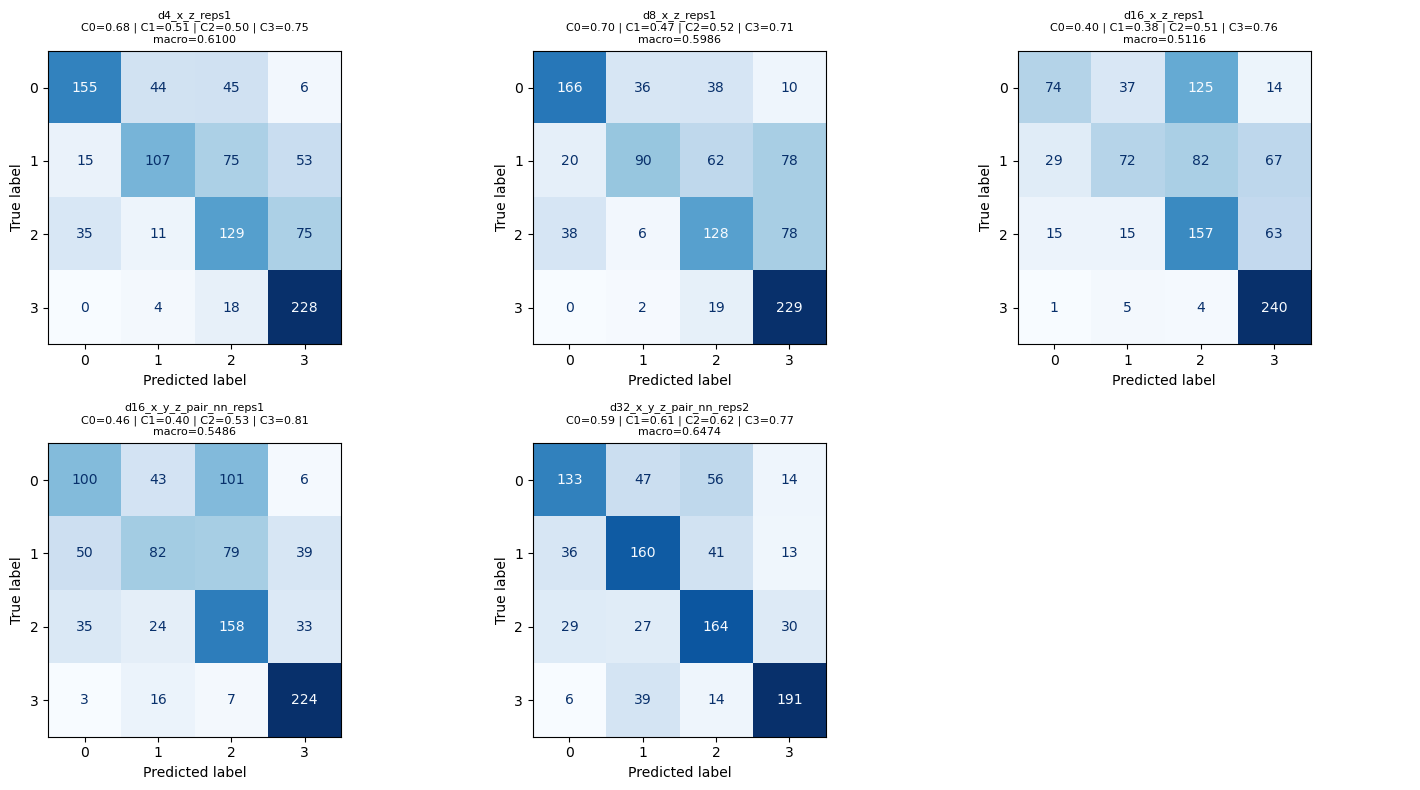

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math
import os

seed = CURRENT_SEED

# lista tag coerente con il tuo training loop
tags = [f"d{exp['d']}_{exp['readout']}_reps{exp['reps']}" for exp in EXPERIMENTS]

n = len(tags)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

# mappa tag -> F1 dal tuo results_summary
f1_map = {
    r['tag']: r['test_f1']
    for r in results_summary
    if r.get('status') == 'OK'
}

from sklearn.metrics import f1_score

for i, tag in enumerate(tags):
    path = f'../artifacts/vqc_realAmpl_{tag}_seed_{seed}_predss.npz'
    ax = axes[i]

    if not os.path.exists(path):
        ax.set_title(f"{tag}\nMISSING")
        ax.axis("off")
        continue

    data = np.load(path)
    y_true = data["test_y_true"]
    y_pred = data["test_y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")

    # F1 per classe
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    f1_macro = f1_map.get(tag, None)

    title = f"{tag}\n"
    title += " | ".join([f"C{c}={f1_per_class[c]:.2f}" for c in range(len(f1_per_class))])
    if f1_macro is not None:
        title += f"\nmacro={f1_macro:.4f}"
    ax.set_title(title, fontsize=8)

# spegni assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()